In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from service import SeattleBuildingService
from BuildingInput import BuildingInput


In [2]:
service = SeattleBuildingService()

In [3]:
df_esti = pd.read_csv('./data/projet6_estimation.csv')

In [4]:
row_dic = df_esti.loc[0].to_dict()
#input_obj = BuildingInput (**row.to_dict() )

#predictions = [service.predict ( BuildingInput (**row.to_dict() ) ) ["prediction_tCO2"] for _, row in df_esti.iterrows()]
#predictions = service.predict (row_dic )

predictions = [
    service.predict(BuildingInput(**row.to_dict()))["prediction_tCO2"]
    for _, row in df_esti.iterrows()
]

# 2. Assignation des prédictions dans le DataFrame de test
data_test = df_esti.copy()
data_test["prediction"] = predictions





In [5]:
data_test["TotalGHGEmissions"].describe()

count     96.000000
mean      81.583750
std       81.843537
min        2.340000
25%       22.115000
50%       52.415000
75%       94.692500
max      359.090000
Name: TotalGHGEmissions, dtype: float64

In [6]:
data_test["prediction"].describe()

count     96.000000
mean      97.627813
std       84.115870
min        3.140000
25%       32.895000
50%       77.025000
75%      130.037500
max      325.080000
Name: prediction, dtype: float64

In [7]:
# Total cumulé réels vs prédits
total_reel = data_test["TotalGHGEmissions"].sum()
total_predit = data_test["prediction"].sum()
ratio_global_pct = (total_predit / total_reel) * 100
# Erreur Pourcentage Moyenne Absolue (MAPE)

mape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).mean()
    * 100
)

# Erreur Médiane Pourcentage Absolue (MdAPE) - Résistante aux valeurs aberrantes
mdape = (
    np.abs(
        (data_test["TotalGHGEmissions"] - data_test["prediction"])
        / data_test["TotalGHGEmissions"]
    ).median()
    * 100
)

# 5. Affichage des résultats
print(f"--- RÉSULTATS GLOBAUX DU MODÈLE ---")
print(
    f"Volume réel total      : {total_reel:,.2f} tCO2e"
)
print(
    f"Volume prédit total     : {total_predit:,.2f} tCO2e"
)
print(
    f"Ratio global de volume  : {ratio_global_pct:.2f}% "
)
print(f"Erreur moyenne (MAPE)   : {mape:.2f}%")
print(f"Erreur médiane (MdAPE)  : {mdape:.2f}%")

--- RÉSULTATS GLOBAUX DU MODÈLE ---
Volume réel total      : 7,832.04 tCO2e
Volume prédit total     : 9,372.27 tCO2e
Ratio global de volume  : 119.67% 
Erreur moyenne (MAPE)   : 39.70%
Erreur médiane (MdAPE)  : 30.33%


In [8]:
data_test["ecart"] =data_test["TotalGHGEmissions"] - data_test["prediction"] 

data_test["ratio_pct"] = ( data_test["prediction"]/ data_test["TotalGHGEmissions"]) *100

data_test["ratio_erreur_pct"] = (
    (data_test["prediction"] - data_test["TotalGHGEmissions"])
    / data_test["TotalGHGEmissions"]
) * 100

In [9]:
display (data_test[["BuildingType", "ENERGYSTARScore","TotalGHGEmissions" ,"prediction", "ecart", "ratio_pct" , "ratio_erreur_pct", "BuildingAge"] ].sort_values(by ="BuildingAge"))

,BuildingType,ENERGYSTARScore,TotalGHGEmissions,prediction,ecart,ratio_pct,ratio_erreur_pct,BuildingAge
27,SPS-District K-12,75.0,80.08,147.09,-67.01,183.678821,83.678821,6
91,SPS-District K-12,84.0,124.77,171.74,-46.97,137.645267,37.645267,7
59,SPS-District K-12,77.0,24.42,32.34,-7.92,132.432432,32.432432,8
14,SPS-District K-12,60.0,359.09,323.81,35.28,90.175165,-9.824835,8
40,SPS-District K-12,94.0,226.06,172.25,53.81,76.196585,-23.803415,9
...,...,...,...,...,...,...,...,...
77,SPS-District K-12,92.0,94.85,113.68,-18.83,119.852399,19.852399,91
90,SPS-District K-12,90.0,46.70,56.70,-10.00,121.413276,21.413276,91
41,NonResidential,71.0,148.11,148.60,-0.49,100.330835,0.330835,95
42,NonResidential,83.0,22.39,18.00,4.39,80.393033,-19.606967,107


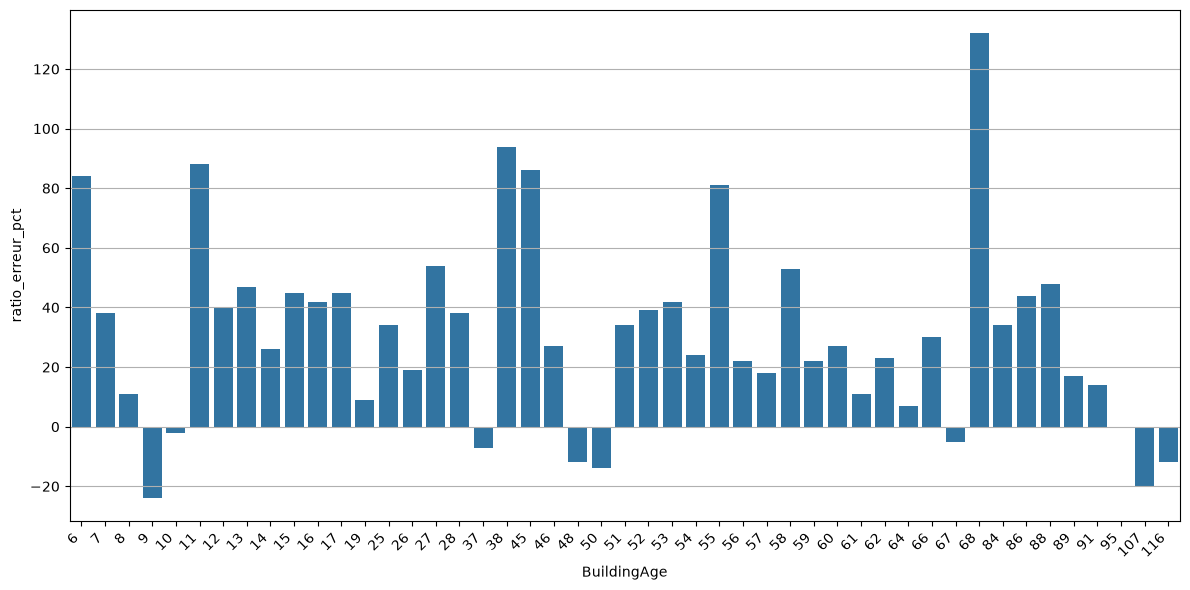

In [10]:
plt.figure(figsize=(12,6))
consommation_par_type = data_test.groupby('BuildingAge')['ratio_erreur_pct'].mean().sort_values(ascending=True).round(0)
sns.barplot(data=consommation_par_type)
plt.xticks(rotation=45, ha='right') 
plt.grid(axis='y')
plt.tight_layout()